# Budget sweep — read-only

Every number here comes from `<run>/seed_*/<arm>/summary.json`. Nothing is refitted and nothing
is rescored, so this notebook runs in seconds and cannot disagree with the sweep that produced
the data.

`compare_all_methods.ipynb` writes all of it: infidelity, SPAM, diamond distance and the
accounted shot budget, for the POUNDERS arms and the LM arms alike. Diamond distance needs
cvxpy + cvxopt **in the environment that runs the sweep** — not here.

Arms are discovered from the folder names, so anything the sweep adds later shows up without
editing this notebook.

**Gone from the old version:** `adaptive_D + polish`, `LM MLE (standalone)` and `LM + FPR` used
to be fitted here. The last two are now real arms (`lm_mle`, `lm_fpr`) written by the sweep. The
polish is not — it was a post-hoc refit on a redrawn dataset, and the inline LM checkpoints
(`lm_checkpoints.csv`, `LM_CKPT_ENABLED`) answer the same question on the data POUNDERS actually
measured.

In [11]:
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DIR = Path.cwd()                       # run from seed_sweep_experiments
warnings.filterwarnings("ignore")

# summary.json keys -> the short column names used below
INF_KEY   = "mean_gate_entanglement_infidelity_to_truth"
DD_KEY    = "mean_gate_diamond_distance_to_truth"
SPAM_KEY  = "mean_spam_vector_l2_error_to_truth"
# Trace distance is the operational SPAM error: 1/2 ||rho - sigma||_1 is exactly the
# advantage of the best possible single-shot discriminator between the two states, and
# povm_jtracedist is its POVM analogue. The L2 above is a distance between Pauli-basis
# coefficient VECTORS -- basis-dependent, and no operational reading. Both are plotted
# only if you add SPAM_KEY back to METRICS; the figure uses the trace distance.
SPAM_TD_KEY = "mean_spam_tracedist_to_truth"
SHOTS_KEY = "accounted_revealed_shots"

# None = every seed folder on disk; a list restricts to those seeds. Unequal n across budgets
# is fine -- the plots take a median per run folder, so it only means some medians are better
# estimated. Discarding folders to balance n throws away real data.
SEEDS = None

# Restrict to arms that fit on the FULL circuit design, dropping the FPR-reduced ones
# (fixed_fpr ~819 circuits, adaptive_D ~833, lm_fpr ~442 of 1918). With those gone every
# remaining arm sees the same 1918 circuits, so a difference between them is a difference in
# ALLOCATION and nothing else -- the FPR arms confound allocation with circuit selection, and
# we already know the reduction costs more than the allocation gains.
#
# The test is on the data (revealed_circuits == total_circuits), not a list of arm names, so
# a new FPR variant is excluded without editing this and a new full-design arm is included.
FULL_CIRCUITS_ONLY = True

# Which adaptive_D_nofpr_fXXX baseline fractions to keep. All eight on one axis makes the
# legend longer than the plot and the median tables too wide to read, so pick the ones the
# figure is actually about. None keeps every fraction.
#
# This filters the LOADED TABLE, so it trims the plots and the median tables together. It
# does not affect the cached recompute below, which always covers every arm on disk -- so
# changing this list is instant and never triggers a recomputation.
#
# Only arms ending in _fNNN are affected. Plain `adaptive_D_nofpr` (the run at the config's
# own default fraction) is a different arm and is always kept.
SHOW_FRACTIONS = [0.05,0.1]

# Arms to drop outright, whatever else they pass. `adaptive_D_nofpr` (the run at the config's
# own default fraction) exists only at the 500 and 1000 budgets -- phase A at 250/1500/2000
# ran fixed_fpr, fixed_no_fpr, lm and lm_mle only -- so it draws a two-point line across a
# five-point axis, which reads as a trend rather than as missing data. The fXXX arms cover
# the same ground at every budget.
# fixed_no_fpr is hidden because the figure compares the LM baselines against the
# fraction sweep; it is the uniform-allocation control and is worth putting back (just
# drop it from this list) whenever the question is "does adapting beat not adapting".
HIDE_ARMS = ["adaptive_D_nofpr", "fixed_no_fpr"]

RUN_GLOB = "all_methods_comparison*"
RUNS = [r for r in sorted(DIR.glob(RUN_GLOB)) if r.is_dir()]


def seed_dirs(run):
    """The run's seed folders; all of them when SEEDS is None."""
    return [sd for sd in sorted(run.glob("seed_*"))
            if SEEDS is None or int(sd.name.split("_")[1]) in SEEDS]


def _num(d, key):
    """summary.json value as a float, with a missing or null key becoming NaN."""
    v = d.get(key)
    try:
        return float(v)
    except (TypeError, ValueError):
        return float("nan")


def _from_trajectory(arm, summ, keys):
    """Backfill metrics an older arm did not write into summary.json.

    The LM arms write lm_trajectory.csv with one row per max-length stage, and the LAST row is
    the final estimate. Only trust it when its infidelity matches summary.json -- that proves
    the two describe the same model rather than a stale file."""
    traj = arm / "lm_trajectory.csv"
    if not traj.exists() or not any(k not in summ for k in keys):
        return {}
    try:
        t = pd.read_csv(traj)
    except Exception:
        return {}
    if t.empty:
        return {}
    last = t.iloc[-1]
    if INF_KEY in t.columns and INF_KEY in summ:
        if abs(last[INF_KEY] - summ[INF_KEY]) > 1e-9 * max(abs(summ[INF_KEY]), 1e-30):
            return {}
    return {k: last[k] for k in keys if k not in summ and k in t.columns}



def _spam_td_from_csv(arm, summ):
    """Backfill mean_spam_tracedist_to_truth from final_spam_errors.csv.

    The LM arms compute the trace distance (aligned_error_metrics does it unconditionally)
    but older lm_arms.py copied only three keys into summary.json, so the aggregate is
    missing there while the per-member rows survive. nanmean over the truth-referenced rows
    is the same reduction aligned_error_metrics applies -- the prep trace distance and the
    POVM Jamiolkowski trace distance, with the per-outcome effect rows carrying NaN.

    Returns {} when the key is already present, so a run that wrote it properly is never
    second-guessed by a recomputation.
    """
    if SPAM_TD_KEY in summ:
        return {}
    f = arm / "final_spam_errors.csv"
    if not f.exists():
        return {}
    try:
        t = pd.read_csv(f)
    except Exception:
        return {}
    if "tracedist" not in t.columns:
        return {}
    if "reference" in t.columns:
        t = t[t["reference"] == "truth"]
    v = t["tracedist"].astype(float)
    if v.notna().sum() == 0:
        return {}
    return {SPAM_TD_KEY: float(v.mean(skipna=True))}

def load():
    """One row per (run folder, seed, arm), straight from summary.json.

    Arms are whatever subdirectories carry a summary.json, so a new arm in the sweep needs no
    change here. `objective` records which residual the arm minimised (weighted_least_squares
    vs poisson_logl for POUNDERS, chi2_ladder_then_mle vs pure_mle for the LM arms) so WLS and
    logl sweeps can be told apart if they share a folder."""
    rows = []
    for run in RUNS:
        for sd in seed_dirs(run):
            for arm in sorted(p for p in sd.iterdir() if p.is_dir()):
                f = arm / "summary.json"
                if not f.exists():
                    continue
                s = json.loads(f.read_text())
                s = {**_from_trajectory(arm, s, (INF_KEY, DD_KEY, SPAM_KEY, SPAM_TD_KEY)),
                     **s}
                s = {**s, **_spam_td_from_csv(arm, s)}
                rows.append(dict(run=run.name, seed=int(sd.name.split("_")[1]),
                                 method=arm.name,
                                 shots=_num(s, SHOTS_KEY),
                                 infidelity=_num(s, INF_KEY),
                                 diamond=_num(s, DD_KEY),
                                 spam=_num(s, SPAM_KEY),
                                 spam_td=_num(s, SPAM_TD_KEY),
                                 circuits=_num(s, "revealed_circuits"),
                                 total_circuits=_num(s, "total_circuits"),
                                 objective=s.get("objective_mode") or s.get("objective")))
    return pd.DataFrame(rows)


df = load()
if df.empty:
    raise FileNotFoundError(
        f"No summary.json under {DIR}/{RUN_GLOB}/seed_*/*/ . Run compare_all_methods first.")

if FULL_CIRCUITS_ONLY:
    # nunique over the ratio, per arm: an arm counts as full-design only if EVERY run of it
    # revealed every circuit. An arm that is full in one budget and reduced in another would
    # otherwise be pooled across two different designs.
    frac = df.groupby("method").apply(
        lambda g: (g["circuits"] / g["total_circuits"]).min(), include_groups=False)
    full = set(frac[frac >= 1.0 - 1e-9].index)
    dropped = sorted(set(df["method"]) - full)
    if dropped:
        _d = df[df["method"].isin(dropped)].groupby("method")["circuits"].median()
        print("FULL_CIRCUITS_ONLY -- dropped " + ", ".join(
            f"{m} ({int(_d[m])} circ)" for m in dropped))
    df = df[df["method"].isin(full)].reset_index(drop=True)
    if df.empty:
        raise ValueError("FULL_CIRCUITS_ONLY removed every arm -- check revealed_circuits")
    print()

if SHOW_FRACTIONS is not None:
    _keep = {int(round(float(f) * 100)) for f in SHOW_FRACTIONS}
    _pat = re.compile(r"_f(\d{3})$")
    _drop = sorted(m for m in set(df["method"])
                   if (_m := _pat.search(str(m))) and int(_m.group(1)) not in _keep)
    if _drop:
        print("SHOW_FRACTIONS -- hiding " + ", ".join(
            f"{int(_pat.search(m).group(1)) / 100:g}" for m in _drop)
            + f"  ({len(_drop)} arms; set SHOW_FRACTIONS = None to show all)")
    df = df[~df["method"].isin(_drop)].reset_index(drop=True)
    _missing = _keep - {int(_pat.search(m).group(1)) for m in set(df["method"])
                        if _pat.search(str(m))}
    if _missing:
        print("  !! asked for fraction(s) with no arm on disk: "
              + ", ".join(f"{v / 100:g}" for v in sorted(_missing)))
    print()

if HIDE_ARMS:
    _present = sorted(set(HIDE_ARMS) & set(df["method"]))
    if _present:
        _at = {m: sorted(df[df["method"] == m]["run"].unique()) for m in _present}
        for m in _present:
            print(f"HIDE_ARMS -- dropping {m} (present in {len(_at[m])} of {len(RUNS)} runs)")
    df = df[~df["method"].isin(HIDE_ARMS)].reset_index(drop=True)
    _absent = sorted(set(HIDE_ARMS) - set(_present))
    if _absent:
        print("  (already absent: " + ", ".join(_absent) + ")")
    print()

for r in RUNS:
    print(f"{r.name}: {len(seed_dirs(r))} of {len(list(r.glob('seed_*')))} seed folders")
print()
print(df.groupby("method").agg(
    rows=("seed", "size"), seeds=("seed", "nunique"), budgets=("run", "nunique"),
    with_diamond=("diamond", lambda v: int(v.notna().sum())),
    with_spam=("spam", lambda v: int(v.notna().sum())),
    with_spam_td=("spam_td", lambda v: int(v.notna().sum())),
    objective=("objective", lambda v: "/".join(sorted(set(v.dropna())) or ["-"]))
).to_string())

_missing = df.groupby("method")["diamond"].apply(lambda v: v.isna().all())
if _missing.any():
    print("\nno diamond distance for: " + ", ".join(_missing[_missing].index) +
          "\n  -> those runs predate report_diamond_distance, or the sweep environment "
          "lacked cvxpy/cvxopt. Re-run them to fill it in.")

FULL_CIRCUITS_ONLY -- dropped fixed_fpr (853 circ)

SHOW_FRACTIONS -- hiding 0.2, 0.3, 0.4, 0.5, 0.6, 0.7  (6 arms; set SHOW_FRACTIONS = None to show all)

HIDE_ARMS -- dropping fixed_no_fpr (present in 8 of 8 runs)
  (already absent: adaptive_D_nofpr)

all_methods_comparison_1000: 10 of 10 seed folders
all_methods_comparison_150: 10 of 10 seed folders
all_methods_comparison_1500: 10 of 10 seed folders
all_methods_comparison_2000: 10 of 10 seed folders
all_methods_comparison_250: 10 of 10 seed folders
all_methods_comparison_4000: 10 of 10 seed folders
all_methods_comparison_500: 10 of 10 seed folders
all_methods_comparison_6000: 10 of 10 seed folders

                       rows  seeds  budgets  with_diamond  with_spam  with_spam_td             objective
method                                                                                                  
adaptive_D_nofpr_f005    80     10        8            80         80            80          poisson_logl
adaptive_D_nofpr_f010    

## Plots

arms found: ['lm', 'lm_mle', 'adaptive_D_nofpr_f005', 'adaptive_D_nofpr_f010']
  POUNDERS: ['adaptive_D_nofpr_f005', 'adaptive_D_nofpr_f010']
  LM      : ['lm', 'lm_mle']


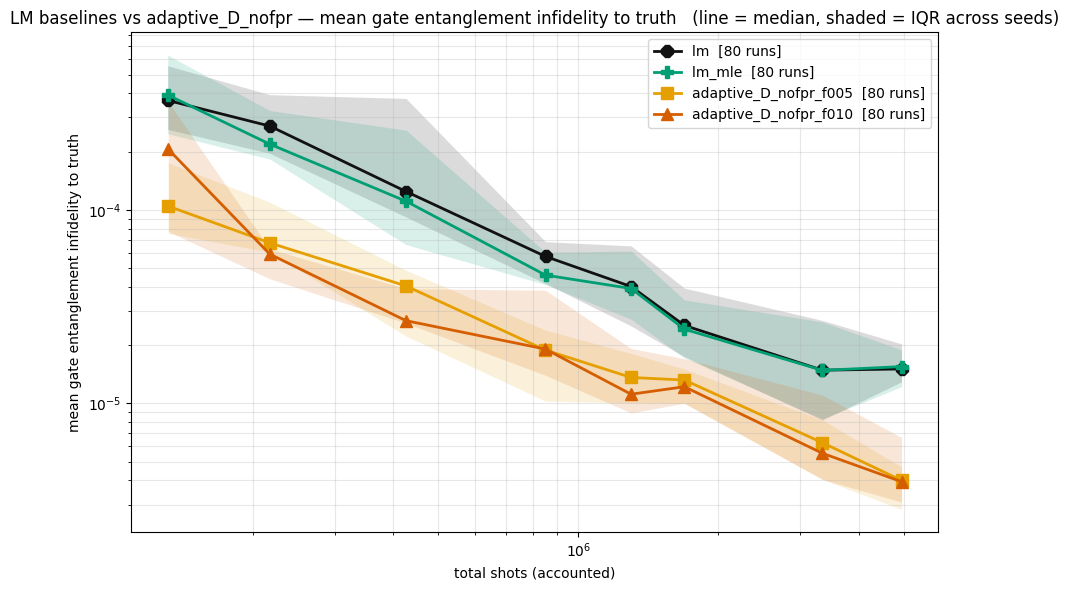

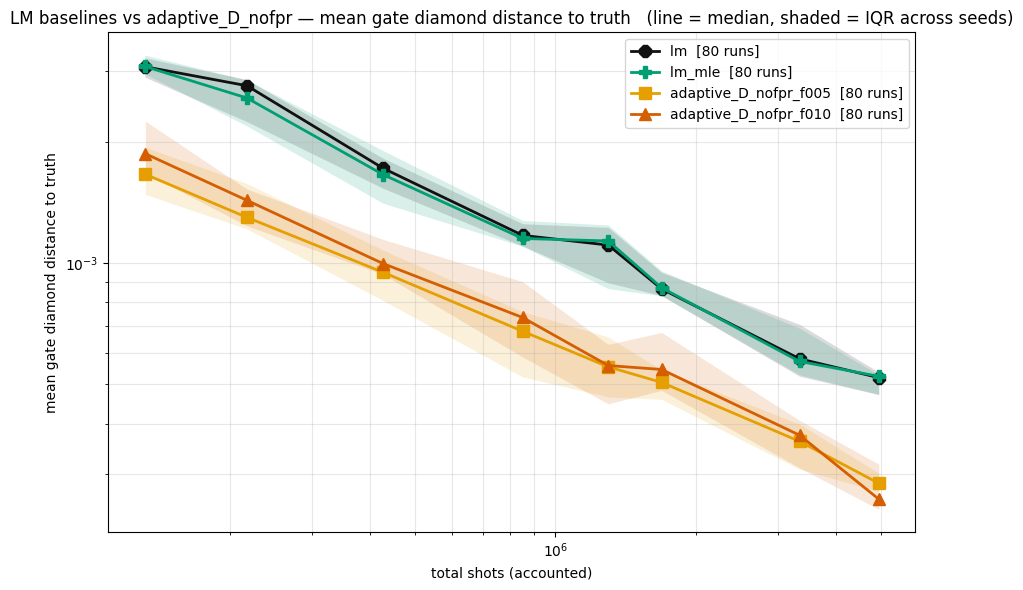

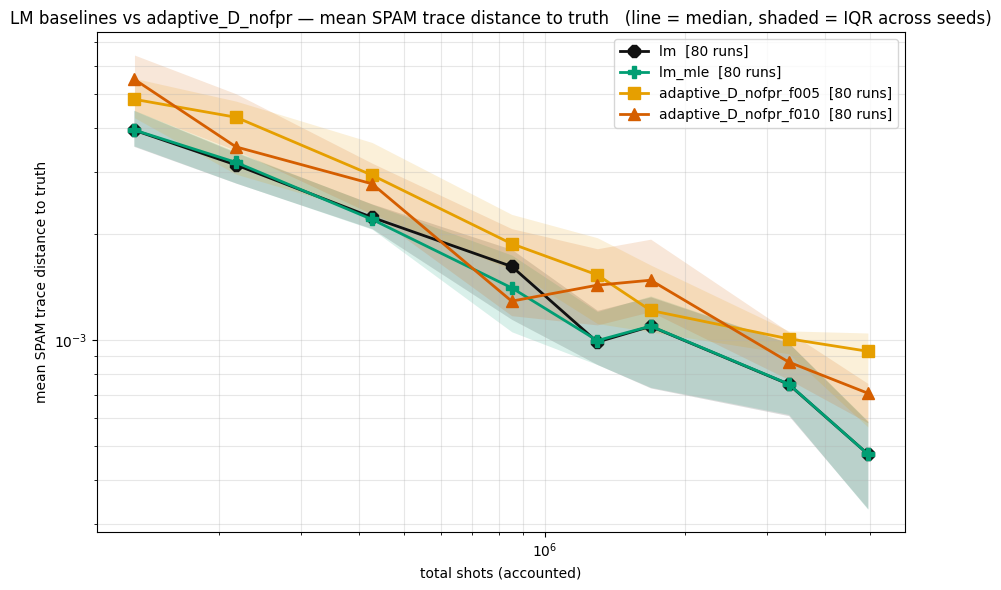

figures written to /workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments

median mean gate entanglement infidelity to truth by budget
method                       adaptive_D_nofpr_f005  adaptive_D_nofpr_f010        lm    lm_mle
run                                                                                          
all_methods_comparison_1000              1.884e-05              1.906e-05 5.738e-05 4.596e-05
all_methods_comparison_150               1.044e-04              2.055e-04 3.675e-04 3.918e-04
all_methods_comparison_1500              1.360e-05              1.114e-05 4.011e-05 3.919e-05
all_methods_comparison_2000              1.319e-05              1.218e-05 2.526e-05 2.416e-05
all_methods_comparison_250               6.744e-05              5.898e-05 2.707e-04 2.183e-04
all_methods_comparison_4000              6.260e-06              5.521e-06 1.483e-05 1.480e-05
all_methods_comparison_500               4.043e-05              2.674e-05 1.243e-04 1.107e-04
all_methods_comparis

In [12]:
# Colours/markers keyed on the ARM FOLDER NAME, which is what `method` holds.
STYLE = {"fixed_no_fpr": ("#2E7D32", "p"), "fixed_fpr": ("#7F3C00", "h"),
         "adaptive_D": ("#B00068", "o"), "adaptive_A": ("#56B4E9", "D"),
         "adaptive_L": ("#CC79A7", "v"),
         "lm": ("#111111", "8"), "lm_mle": ("#009E73", "P"), "lm_fpr": ("#0072B2", "X")}
_SPARE = [("#E69F00", "s"), ("#D55E00", "^"), ("#0072B2", "d"), ("#999999", "*"),
          ("#1F77B4", "<"), ("#2CA02C", ">"), ("#9467BD", "P"), ("#17BECF", "X"),
          ("#BCBD22", "8"), ("#E377C2", "H")]
for _i, _m in enumerate(sorted(set(df["method"]) - set(STYLE))):
    STYLE[_m] = _SPARE[_i % len(_SPARE)]

# The first three are computed after gaugeopt and so depend on gaugeopt_spam_weight; the
# last two do not depend on any gauge choice. See the "Gauge-free metrics" section above.
# Straight from summary.json. Both are computed after gaugeopt_to_target, so both depend
# on the config's gaugeopt_spam_weight -- worth stating anywhere these numbers are quoted.
# Read the SPAM panel with more caution than the other two. A gauge transformation acts
# on gates by conjugation (G -> M G M^-1), so gate eigenvalues -- and hence a lot of what
# infidelity and diamond distance see -- survive it. It acts on SPAM one-sidedly
# (rho -> M rho, E -> E M^-1), so there is no comparable invariant: part of any SPAM error
# reported here is the residual of gaugeopt_to_target, and it moves with the config's
# gaugeopt_spam_weight. SPAM differences BETWEEN arms are still meaningful because every
# arm is gauge-fixed the same way; the absolute level is not.
METRICS = (("infidelity", "mean gate entanglement infidelity to truth"),
           ("diamond",    "mean gate diamond distance to truth"),
           ("spam_td",    "mean SPAM trace distance to truth"))

# Spread around the median, across the seeds within each run folder.
#   "iqr"  - shaded 25th-75th percentile band (readable with several series overlapping)
#   "bars" - capped error bars at the same quartiles
#   "none" - median line only
# The quartiles are over as few as 3 seeds at some budgets, so read a narrow band as
# "few runs" rather than "precise". The legend carries the count per series.
SPREAD = "iqr"


def plot(methods, title, prefix, metrics=METRICS):
    """One figure per metric: median across seeds per run folder, versus accounted shots."""
    methods = [m for m in dict.fromkeys(methods) if m in set(df["method"])]
    for metric, ylabel in metrics:
        fig, ax = plt.subplots(figsize=(9, 6))
        drawn = False
        for m in methods:
            a = df[df["method"] == m].dropna(subset=[metric, "shots"])
            if a.empty:
                continue
            g = (a.groupby("run").agg(x=("shots", "median"), y=(metric, "median"),
                                      lo=(metric, lambda v: v.quantile(0.25)),
                                      hi=(metric, lambda v: v.quantile(0.75)),
                                      n=("seed", "nunique")).sort_values("x"))
            c, mk = STYLE.get(m, ("grey", "o"))
            if SPREAD == "iqr":
                ax.fill_between(g["x"], g["lo"], g["hi"], color=c, alpha=0.15, lw=0)
            elif SPREAD == "bars":
                ax.errorbar(g["x"], g["y"],
                            yerr=np.vstack([(g["y"] - g["lo"]).values,
                                            (g["hi"] - g["y"]).values]),
                            fmt="none", ecolor=c, elinewidth=1.2, capsize=4, alpha=0.75)
            ax.plot(g["x"], g["y"], color=c, marker=mk, ms=9, lw=2,
                    label=f"{m}  [{int(g['n'].sum())} runs]")
            drawn = True
        if not drawn:
            plt.close(fig)
            print(f"({title}: no data for {metric})")
            continue
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("total shots (accounted)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title} — {ylabel}"
                     + ("   (line = median, shaded = IQR across seeds)" if SPREAD == "iqr"
                        else "   (line = median, bars = IQR across seeds)" if SPREAD == "bars"
                        else "   (median across seeds)"))
        ax.grid(alpha=0.3, which="both")
        ax.legend()
        fig.tight_layout()
        fig.savefig(DIR / f"{prefix}_{metric}.png", dpi=150, bbox_inches="tight")
        plt.show()


# ---- arm discovery -------------------------------------------------------------------
# Groups are derived from whatever is on disk, so a new arm (adaptive_D_nofpr, adaptive_A,
# a second criterion, ...) is plotted without editing this cell. PREFERRED fixes the order
# of the arms that already existed; anything else is appended alphabetically.
PREFERRED = ["fixed_no_fpr", "fixed_fpr",
             "adaptive_D", "adaptive_D_nofpr", "adaptive_A", "adaptive_A_nofpr",
             "adaptive_L", "adaptive_L_nofpr",
             "lm", "lm_mle", "lm_fpr"]

def order(ms):
    ms = set(ms)
    head = [m for m in PREFERRED if m in ms]
    return head + sorted(ms - set(head))

ALL_ARMS = order(df["method"].dropna().unique())
LM_ARMS = [m for m in ALL_ARMS if m.startswith("lm")]
POUNDERS_ARMS = [m for m in ALL_ARMS if m not in LM_ARMS]
ADAPTIVE_ARMS = [m for m in POUNDERS_ARMS if m.startswith("adaptive")]
print("arms found:", ALL_ARMS)
print("  POUNDERS:", POUNDERS_ARMS)
print("  LM      :", LM_ARMS)

# One figure per metric: every LM baseline against every adaptive_D_nofpr fraction, at
# matched revealed shots. Two metrics x one arm group = two figures.
#   lm      = pyGSTi defaults: chi2 up the max-length ladder, one dlogl at the end
#   lm_mle  = dlogl at every ladder stage, no chi2 warmup, same 1918-circuit design
#   *_fNNN  = adaptive allocation, no FPR, NNN/100 of the budget spent uniformly first
plot(LM_ARMS + ADAPTIVE_ARMS, "LM baselines vs adaptive_D_nofpr", "cmp")

print("figures written to", DIR)


# ---- median table, one row per budget -------------------------------------------------
for metric, ylabel in METRICS:
    piv = df.pivot_table(index="run", columns="method", values=metric, aggfunc="median")
    if piv.dropna(how="all").empty:
        continue
    print(f"\nmedian {ylabel} by budget")
    print(piv.to_string(float_format=lambda v: f"{v:.3e}"))